In [ ]:
Write a program to work with time series data using NumPy and pandas
Problem Statement: A time series dataset representing daily temperatures over a year.
You will perform some basic analysis and visualization using NumPy, pandas, and
matplotlib.

First 5 rows:
            Temperature
Date                   
2025-01-01    20.993428
2025-01-02    19.896078
2025-01-03    21.640538
2025-01-04    23.563673
2025-01-05    20.221605

Summary Statistics:
count    365.000000
mean      20.019893
std        7.242015
min        3.697190
25%       13.378202
50%       20.277570
75%       26.464471
max       34.214047
Name: Temperature, dtype: float64

Monthly Average Temperature:
Date
2025-01-31    22.127009
2025-02-28    26.594282
2025-03-31    29.546724
2025-04-30    29.580976
2025-05-31    26.998013
2025-06-30    23.361126
2025-07-31    17.831945
2025-08-31    13.030397
2025-09-30    10.280933
2025-10-31    10.578128
2025-11-30    13.472731
2025-12-31    17.363525
Freq: ME, Name: Temperature, dtype: float64


/tmp/ipykernel_3299/2178368894.py:35: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df['Temperature'].resample('M').mean()


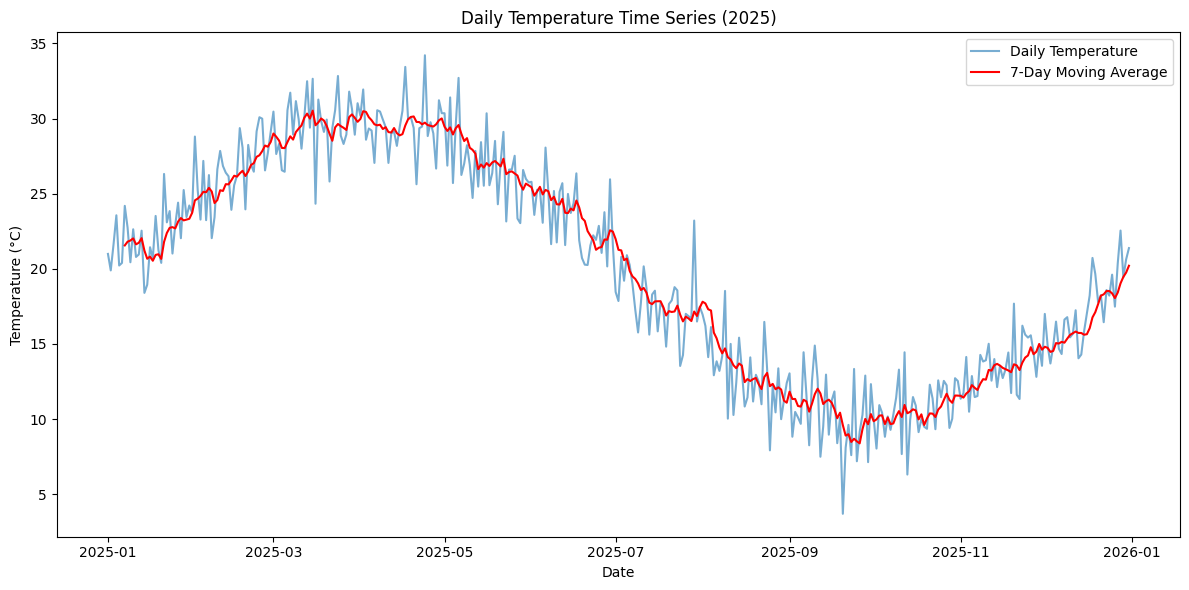

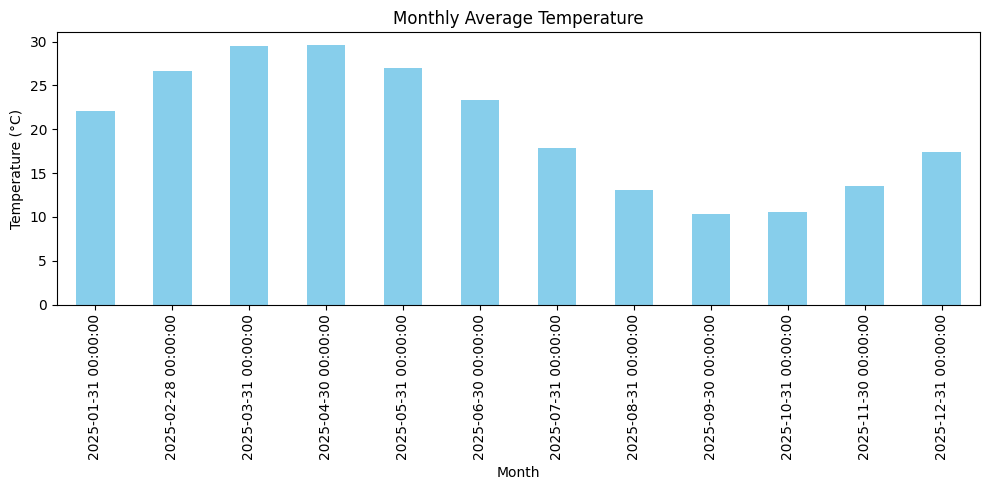

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# Generate sample time series data (1 year)
# -----------------------------------
dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')

# Generate synthetic temperature data using NumPy
np.random.seed(42)
temperatures = 20 + 10 * np.sin(np.linspace(0, 2 * np.pi, len(dates))) \
               + np.random.normal(0, 2, len(dates))

# Create DataFrame
df = pd.DataFrame({
    'Date': dates,
    'Temperature': temperatures
})

# Set Date as index
df.set_index('Date', inplace=True)

print("First 5 rows:")
print(df.head())

# -----------------------------------
# Basic Analysis
# -----------------------------------
print("\nSummary Statistics:")
print(df['Temperature'].describe())

# Monthly average temperature
monthly_avg = df['Temperature'].resample('M').mean()
print("\nMonthly Average Temperature:")
print(monthly_avg)

# Rolling average (7-day moving average)
df['7-day MA'] = df['Temperature'].rolling(window=7).mean()

# -----------------------------------
# Visualization
# -----------------------------------
plt.figure(figsize=(12, 6))

# Plot original data
plt.plot(df.index, df['Temperature'], label='Daily Temperature', alpha=0.6)

# Plot moving average
plt.plot(df.index, df['7-day MA'], label='7-Day Moving Average', color='red')

plt.title('Daily Temperature Time Series (2025)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------------
# Monthly Average Bar Plot
# -----------------------------------
plt.figure(figsize=(10, 5))
monthly_avg.plot(kind='bar', color='skyblue')

plt.title('Monthly Average Temperature')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')

plt.tight_layout()
plt.show()